# Hard-Margin SVM
Using the **Iris dataset** (two linearly separable classes: Setosa vs Versicolor, two features).

We follow exactly the derivation from Part 1:
1. Solve the **dual QP** to get $\alpha^*$
2. Recover $\mathbf{w}^*$ and $b^*$ via KKT stationarity
3. Identify **support vectors** via complementary slackness
4. Visualise the margin

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.optimize import minimize

## 1. Load Data
Iris classes 0 (Setosa) and 1 (Versicolor) are linearly separable in features 0 & 2 (sepal length, petal length).

In [3]:
iris = load_iris()
mask = iris.target < 2          # keep only classes 0 and 1
X = iris.data[mask][:, [0, 2]]  # sepal length, petal length
y = np.where(iris.target[mask] == 0, -1.0, 1.0)  # labels in {-1, +1}

# normalise so the QP is well-conditioned
X = (X - X.mean(axis=0)) / X.std(axis=0)

N = len(y)
print(f"{N} points  |  class -1: {(y==-1).sum()}  class +1: {(y==1).sum()}")

100 points  |  class -1: 50  class +1: 50


## 2. Solve the Dual QP
$$\max_{\alpha}\;\sum_i \alpha_i - \frac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j \langle x_i, x_j\rangle \qquad \text{s.t.}\quad \alpha_i\geq 0,\;\sum_i\alpha_i y_i=0$$

In [4]:
# Gram matrix  Q[i,j] = y_i y_j <x_i, x_j>
Q = np.outer(y, y) * (X @ X.T)

res = minimize(
    fun=lambda a: 0.5 * (a @ Q @ a) - a.sum(),
    x0=np.zeros(N),
    jac=lambda a: Q @ a - np.ones(N),
    method='SLSQP',
    bounds=[(0, None)] * N,
    constraints={'type': 'eq', 'fun': lambda a: y @ a},
    options={'ftol': 1e-9, 'maxiter': 1000}
)
assert res.success, res.message
alpha = res.x

## 3. Recover $\mathbf{w}^*$, $b^*$ and Support Vectors
From the KKT stationarity conditions:
$$\mathbf{w}^* = \sum_i \alpha_i^* y_i x_i, \qquad b^* = \frac{1}{|\mathcal{S}|}\sum_{s\in\mathcal{S}}\bigl(y_s - \langle\mathbf{w}^*, x_s\rangle\bigr)$$
Complementary slackness: $\alpha_i^* > 0 \Leftrightarrow$ point is a **support vector**.

In [8]:
sv   = alpha > 1e-4                    # complementary slackness threshold
w    = (alpha * y) @ X                 # KKT stationarity eq. (1)
b    = np.mean(y[sv] - X[sv] @ w)     # averaged over all SVs for stability

print(f"w*  = {w}")
print(f"b*  = {b:.4f}")
print(f"Support vectors: {sv.sum()} out of {N} points")
print(f"Margin width: 2/||w|| = {2/np.linalg.norm(w):.4f}")

# sanity check: all points satisfy y_i(w.x_i + b) >= 1
margins = y * (X @ w + b)
print(f"Min functional margin: {margins.min():.4f}  (should be ≥ 1)")

w*  = [5.37347944e-14 2.62233375e+00]
b*  = 0.7473
Support vectors: 2 out of 100 points
Margin width: 2/||w|| = 0.7627
Min functional margin: 1.0000  (should be ≥ 1)


## 4. Visualise

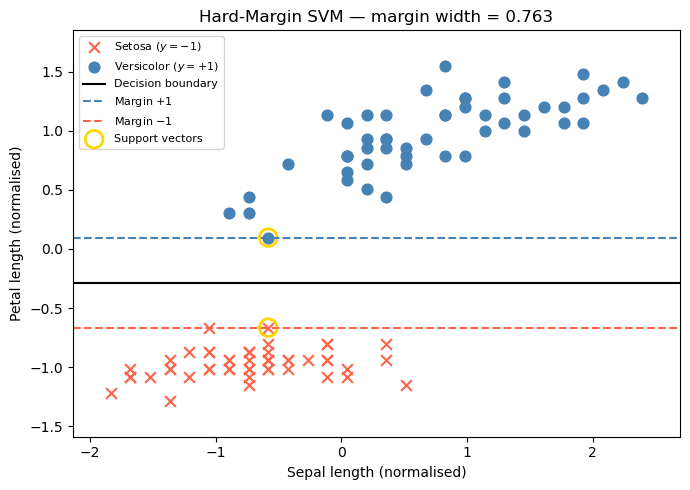

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

# scatter plot
ax.scatter(X[y==-1, 0], X[y==-1, 1], c='tomato',      marker='x', s=60, label='Setosa ($y=-1$)')
ax.scatter(X[y== 1, 0], X[y== 1, 1], c='steelblue',   marker='o', s=60, label='Versicolor ($y=+1$)')

# decision boundary and margin lines
x1 = np.linspace(X[:,0].min()-0.3, X[:,0].max()+0.3, 300)
# w[0]*x + w[1]*x2 + b = c  =>  x2 = (c - b - w[0]*x) / w[1]
for offset, ls, color, label in [(0, '-',  'k',        'Decision boundary'),
                                   (1, '--', 'steelblue','Margin $+1$'),
                                   (-1,'--', 'tomato',   'Margin $-1$')]:
    x2 = (offset - b - w[0]*x1) / w[1]
    ax.plot(x1, x2, linestyle=ls, color=color, linewidth=1.5,
            label=label if offset==0 else label)

# highlight support vectors
ax.scatter(X[sv, 0], X[sv, 1], s=160, facecolors='none',
           edgecolors='gold', linewidths=2, label='Support vectors')

ax.set_xlabel('Sepal length (normalised)')
ax.set_ylabel('Petal length (normalised)')
ax.set_title(f'Hard-Margin SVM — margin width = {2/np.linalg.norm(w):.3f}')
ax.legend(fontsize=8)
ax.set_xlim(X[:,0].min()-0.3, X[:,0].max()+0.3)
ax.set_ylim(X[:,1].min()-0.3, X[:,1].max()+0.3)
plt.tight_layout()
plt.show()